# important: in order to run the codes you need to download and put project_transactions.csv into the same folder as the code file. it was not uploaded to github due to large size. To download use the following link

link:
https://drive.google.com/file/d/1_OZE8eeWzCICsOnovZEGA4bOXGWxQNKT/view?usp=drive_link

## importing necessary libraries and setting style for visualization purposes

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_style("darkgrid")
pd.set_option('display.float_format', lambda x: '%.4f' % x) # to show numbers in the right format

# mini project
### Using "project_transactions.csv" dataset
# The project includes following analysis:
- Houshold analysis
- product analysis
- 

# Key Objectives
* Read data from multiple sources
* Explore the data
* - explore the data types and cast DAY, QUANTITY,STOR_ID and WEEK_NO  to the smallest appropriate data types
  - check for missing data
  - how many unique households and products are in the data?
* create new Columns to aid in analysis
* filter, sort and aggregate data to pinpoint and summarize important information
* build plots to communicate key insights

### reading in the data and cast the datatypes

In [2]:
# identify which data types can be downcast (looking at maximums)
pd.read_csv("project_transactions.csv").describe().round()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
count,2146311.0000,2146311.0000,2146311.0000,2146311.0000,2146311.0000,2146311.0000,2146311.0000,2146311.0000,2146311.0000,2146311.0000,2146311.0000
mean,1056.0000,34048967698.0000,390.0000,2884715.0000,101.0000,3.0000,3268.0000,-1.0000,56.0000,-0.0000,-0.0000
std,605.0000,4723747572.0000,190.0000,3831949.0000,1152.0000,4.0000,9122.0000,1.0000,27.0000,0.0000,0.0000
min,1.0000,26984896261.0000,1.0000,25671.0000,0.0000,0.0000,1.0000,-130.0000,1.0000,-56.0000,-8.0000
25%,548.0000,30407979445.0000,229.0000,917231.0000,1.0000,1.0000,330.0000,-1.0000,33.0000,0.0000,0.0000
50%,1042.0000,32811761450.0000,392.0000,1027960.0000,1.0000,2.0000,372.0000,0.0000,57.0000,0.0000,0.0000
75%,1581.0000,40128035453.0000,555.0000,1132771.0000,1.0000,3.0000,422.0000,0.0000,80.0000,0.0000,0.0000
max,2099.0000,42305362535.0000,711.0000,18316298.0000,89638.0000,840.0000,34280.0000,4.0000,102.0000,0.0000,0.0000


In [3]:
pd.read_csv("project_transactions.csv").info(memory_usage="deep")
# memory usage without casting = 180 MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2146311 entries, 0 to 2146310
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int64  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int64  
 5   SALES_VALUE        float64
 6   STORE_ID           int64  
 7   RETAIL_DISC        float64
 8   WEEK_NO            int64  
 9   COUPON_DISC        float64
 10  COUPON_MATCH_DISC  float64
dtypes: float64(4), int64(7)
memory usage: 180.1 MB


In [4]:
# importing and cast datatypes at once
transactions = pd.read_csv("project_transactions.csv", dtype={"DAY":"int16", "QUANTITY":"int32", "STORE_ID":"int32","WEEK_NO":"int8"})

In [5]:
transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,1364,26984896261,1,842930,1,2.1900,31742,0.0000,1,0.0000,0.0000
1,1364,26984896261,1,897044,1,2.9900,31742,-0.4000,1,0.0000,0.0000
2,1364,26984896261,1,920955,1,3.0900,31742,0.0000,1,0.0000,0.0000
3,1364,26984896261,1,937406,1,2.5000,31742,-0.9900,1,0.0000,0.0000
4,1364,26984896261,1,981760,1,0.6000,31742,-0.7900,1,0.0000,0.0000


### General Exploration

In [6]:
transactions.shape

(2146311, 11)

In [7]:
transactions.info(memory_usage="deep")
# memory usage after casting=137 MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2146311 entries, 0 to 2146310
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   household_key      int64  
 1   BASKET_ID          int64  
 2   DAY                int16  
 3   PRODUCT_ID         int64  
 4   QUANTITY           int32  
 5   SALES_VALUE        float64
 6   STORE_ID           int32  
 7   RETAIL_DISC        float64
 8   WEEK_NO            int8   
 9   COUPON_DISC        float64
 10  COUPON_MATCH_DISC  float64
dtypes: float64(4), int16(1), int32(2), int64(3), int8(1)
memory usage: 137.1 MB


In [8]:
# findind total number of na values
transactions.isna().sum()

household_key        0
BASKET_ID            0
DAY                  0
PRODUCT_ID           0
QUANTITY             0
SALES_VALUE          0
STORE_ID             0
RETAIL_DISC          0
WEEK_NO              0
COUPON_DISC          0
COUPON_MATCH_DISC    0
dtype: int64

In [9]:
# calculate unique housholds in the dataset
transactions["household_key"].nunique()

2099

In [10]:
# finding unique products in household
transactions.PRODUCT_ID.nunique()

84138

## Column Creation

Create two columns:

* A column that captures the `total_discount` by row (sum of `RETAIL_DISC`, `COUPON_DISC`)
* The percentage disount (`total_discount` / `SALES_VALUE`). Make sure this is positive (try `.abs()`).
* If the percentage discount is greater than 1, set it equal to 1. If it is less than 0, set it to 0. 
* Drop the individual discount columns (`RETAIL_DISC`, `COUPON_DISC`, `COUPON_MATCH_DISC`).

Feel free to overwrite the existing transaction DataFrame after making the modifications above.

In [11]:
transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,1364,26984896261,1,842930,1,2.1900,31742,0.0000,1,0.0000,0.0000
1,1364,26984896261,1,897044,1,2.9900,31742,-0.4000,1,0.0000,0.0000
2,1364,26984896261,1,920955,1,3.0900,31742,0.0000,1,0.0000,0.0000
3,1364,26984896261,1,937406,1,2.5000,31742,-0.9900,1,0.0000,0.0000
4,1364,26984896261,1,981760,1,0.6000,31742,-0.7900,1,0.0000,0.0000


In [12]:
# creating two columns: total_discount (sum of discounts) and percentage_discount
# and dropping individual discount columns
transactions = transactions.assign(
    total_discount = transactions["RETAIL_DISC"] + transactions["COUPON_DISC"],
    percentage_discount = (lambda x: (x["total_discount"]/ x["SALES_VALUE"]).abs())).drop(["RETAIL_DISC", "COUPON_DISC", "COUPON_MATCH_DISC"], axis=1)

In [13]:
# cap values above 1, at 1. and values below 0 at 0
transactions["percentage_discount"] = (transactions["percentage_discount"]
                                       .where(transactions["percentage_discount"] < 1, 1.0)
                                       .where(transactions["percentage_discount"] > 0, 0)
)

In [14]:
transactions

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,WEEK_NO,total_discount,percentage_discount
0,1364,26984896261,1,842930,1,2.1900,31742,1,0.0000,0.0000
1,1364,26984896261,1,897044,1,2.9900,31742,1,-0.4000,0.1338
2,1364,26984896261,1,920955,1,3.0900,31742,1,0.0000,0.0000
3,1364,26984896261,1,937406,1,2.5000,31742,1,-0.9900,0.3960
4,1364,26984896261,1,981760,1,0.6000,31742,1,-0.7900,1.0000
...,...,...,...,...,...,...,...,...,...,...
2146306,1598,42305362535,711,92130,1,0.9900,3228,102,0.0000,0.0000
2146307,1598,42305362535,711,114102,1,8.8900,3228,102,0.0000,0.0000
2146308,1598,42305362535,711,133449,1,6.9900,3228,102,0.0000,0.0000
2146309,1598,42305362535,711,6923644,1,4.5000,3228,102,-0.4900,0.1089


## Overall Statistics

Calculate:

* The total sales (sum of `SALES_VALUE`), 
* Total discount (sum of `total_discount`)
* Overall percentage discount (sum of total_discount / sum of sales value)
* Total quantity sold (sum of `QUANTITY`).
* Max quantity sold in a single row. Inspect the row as well. Does this have a high discount percentage?
* Total sales value per basket (sum of sales value / nunique basket_id).
* Total sales value per household (sum of sales value / nunique household_key). 

In [15]:
# total sales
transactions.SALES_VALUE.sum()

6666243.499999999

In [16]:
# total discount
transactions.total_discount.sum()

-1178658.0799999998

In [17]:
# overall percentage discount
transactions["total_discount"].sum() / transactions["SALES_VALUE"].sum()

-0.1768099350106248

In [18]:
# average percent discount
transactions["percentage_discount"].mean()

0.2073244407398103

In [19]:
# total quantity sold
transactions.QUANTITY.sum()

216713611

In [20]:
# maximum of quantity sold in a single row
transactions["QUANTITY"].max()

89638

In [21]:
# to find the row with max quantity
transactions.loc[transactions["QUANTITY"].argmax()]

household_key                 630.0000
BASKET_ID             34749153595.0000
DAY                           503.0000
PRODUCT_ID                6534178.0000
QUANTITY                    89638.0000
SALES_VALUE                   250.0000
STORE_ID                      384.0000
WEEK_NO                        73.0000
total_discount                -13.4500
percentage_discount             0.0538
Name: 1442095, dtype: float64

In [22]:
# total sales value per Basket
transactions["SALES_VALUE"].sum() / transactions["BASKET_ID"].nunique()

28.61797938516092

In [23]:
# total sales values per houshold
transactions["SALES_VALUE"].sum() / transactions["household_key"].nunique()

3175.9140066698424

## Household Analysis

* Plot the distribution of total sales value purchased at the household level. 
* What were the top 10 households by quantity purchased?
* What were the top 10 households by sales value?
* Plot the total sales value for our top 10 households by value, ordered from highest to lowest.


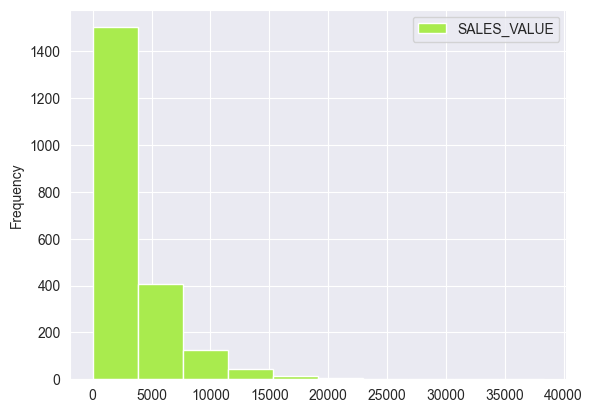

In [31]:
# for distribution we use histogram
# for houshold level we need a groupby household and aggregate sum of sales
transactions.groupby("household_key").agg({"SALES_VALUE":"sum"}).plot.hist(color="#a9eb4e");

In [81]:
# top 10 households by quantity purchased
top_10_quantity = transactions.groupby("household_key").agg({"QUANTITY":"sum"}).sort_values("QUANTITY", ascending=False).head(10)
top_10_quantity

,QUANTITY
household_key,
1023,4479917
755,3141769
1609,2146715
13,1863829
1430,1741892
1527,1734632
1762,1669880
707,1640193
1029,1496204


In [38]:
# top 10 household by sales values
top_10_sales = transactions.groupby("household_key").agg({"SALES_VALUE":"sum"}).sort_values("SALES_VALUE", ascending=False).head(10)
top_10_sales

,SALES_VALUE
household_key,
1023,38319.7900
1609,27859.6800
1453,21661.2900
1430,20352.9900
718,19299.8600
707,19194.4200
1653,19153.7500
1111,18894.7200
982,18790.3400


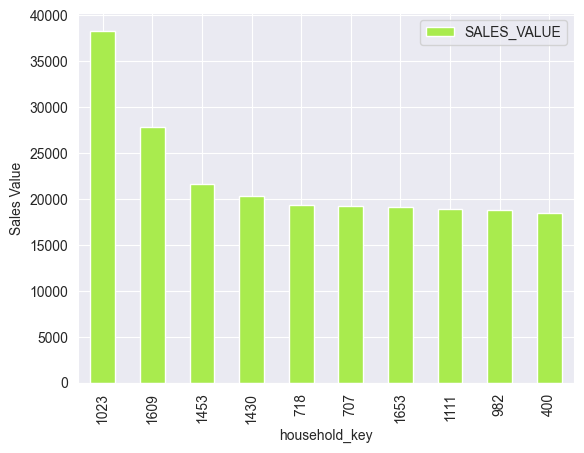

In [92]:
top_10_sales.plot.bar(color="#a9eb4e", ylabel="Sales Value");

## Product Analysis

* Which products had the most sales by sales_value? Plot  a horizontal bar chart.
* Did the top 10 selling items have a higher than average discount rate?
* What was the most common `PRODUCT_ID` among rows with the households in our top 10 households by sales value?
* Look up the names of the  top 10 products by sales in the `products.csv` dataset.
* Look up the product name of the item that had the highest quantity sold in a single row.

In [74]:
# products with the highest sales
top_10_products = transactions.groupby("PRODUCT_ID").agg({"SALES_VALUE":"sum"}).sort_values("SALES_VALUE", ascending = False).head(10)
top_10_products

,SALES_VALUE
PRODUCT_ID,
6534178,420154.1300
6533889,42339.3100
1029743,33894.7500
1082185,24149.7900
6533765,23831.1400
6534166,23755.7000
1106523,22931.0100
916122,22749.0200
995242,21229.7200


<Axes: ylabel='PRODUCT_ID'>

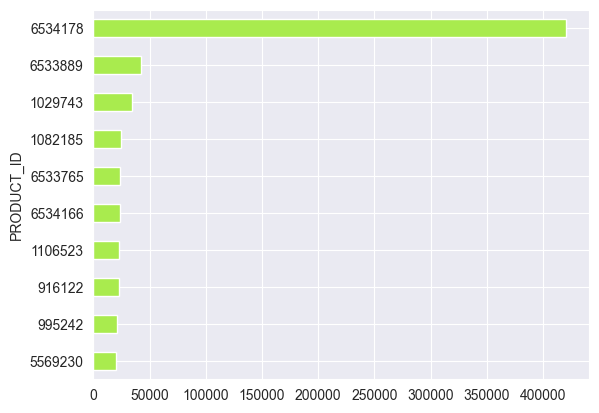

In [75]:
# plotting top 10 products nby sales_value
top_10_products["SALES_VALUE"].sort_values().plot.barh(color="#a9eb4e")

In [76]:
# dividing total discount for top 10 products by sales values
(transactions.query("PRODUCT_ID in @top_10_products.index").loc[:,"total_discount"].sum()) / (transactions.query("PRODUCT_ID in @top_10_products.index").loc[:,"SALES_VALUE"].sum())

-0.10331267387397927

In [79]:
# reading in procudcts data 
products = pd.read_csv("product.csv")
products.head(10)

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ
5,26426,69,GROCERY,Private,SPICES & EXTRACTS,SPICES & SEASONINGS,2.5 OZ
6,26540,69,GROCERY,Private,COOKIES/CONES,TRAY PACK/CHOC CHIP COOKIES,16 OZ
7,26601,69,DRUG GM,Private,VITAMINS,VITAMIN - MINERALS,300CT(1)
8,26636,69,PASTRY,Private,BREAKFAST SWEETS,SW GDS: SW ROLLS/DAN,
9,26691,16,GROCERY,Private,PNT BTR/JELLY/JAMS,HONEY,12 OZ


In [84]:
# top 10 most common product_ID
top_household_products = (transactions
                          .query("household_key in @top_10_sales.index")
                          .loc[:,"PRODUCT_ID"]
                          .value_counts()
                          .head(10)
                          .index
)
top_household_products

Index([1082185, 1029743, 6534178, 6533889, 1127831,  951590,  860776, 1106523,
        981760, 9677202],
      dtype='int64', name='PRODUCT_ID')

In [85]:
# * Look up the names of the  top 10 products by sales in the `products.csv` dataset.
products.query("PRODUCT_ID in @top_household_products")

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
10630,860776,2,PRODUCE,National,VEGETABLES - ALL OTHERS,CUCUMBERS,36 CT
20973,951590,910,GROCERY,National,BAKED BREAD/BUNS/ROLLS,MAINSTREAM WHITE BREAD,20 OZ
24250,981760,69,GROCERY,Private,EGGS,EGGS - X-LARGE,1 DZ
29657,1029743,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
35576,1082185,2,PRODUCE,National,TROPICAL FRUIT,BANANAS,40 LB
38262,1106523,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
40600,1127831,5937,PRODUCE,National,BERRIES,STRAWBERRIES,16 OZ
57181,6533889,69,MISC SALES TRAN,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
57221,6534178,69,KIOSK-GAS,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
68952,9677202,69,GROCERY,Private,PAPER TOWELS,PAPER TOWELS & HOLDERS,


In [87]:
# product with the hightest quantity: --> from before we have PRODUCT_ID = 6534178
# so we query based on this number
products[products["PRODUCT_ID"]==6534178]

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
57221,6534178,69,KIOSK-GAS,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,


In [91]:
# Look up the product name of the item that had the highest quantity sold in a single row.
# we use top_10_products that we have created before: top_10_products

products.query("PRODUCT_ID in @top_10_products.index")

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
16863,916122,4314,MEAT,National,CHICKEN,CHICKEN BREAST BONELESS,
25754,995242,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,
29657,1029743,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
35576,1082185,2,PRODUCE,National,TROPICAL FRUIT,BANANAS,40 LB
38262,1106523,69,GROCERY,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,1 GA
53097,5569230,1208,GROCERY,National,SOFT DRINKS,SOFT DRINKS 12/18&15PK CAN CAR,12 OZ
57171,6533765,69,KIOSK-GAS,Private,FUEL,GASOLINE-REG UNLEADED,
57181,6533889,69,MISC SALES TRAN,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
57216,6534166,69,MISC SALES TRAN,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
57221,6534178,69,KIOSK-GAS,Private,COUPON/MISC ITEMS,GASOLINE-REG UNLEADED,
